In [ ]:
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
fmt = EngFormatter(unit="m", places=None, sep=" ")
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from src.JUDITHDataset import JUDITHDataset, JUDITHPatchDataset

from IPython.display import HTML

# Helpers

In [2]:
# style for pandas table
def center_multiindex_columns(styler):
    # Your existing centering rules
    styler.set_table_styles([
        dict(selector="th.col_heading.level0", props=[("text-align", "center")]),
        dict(selector="th.col_heading.level1", props=[("text-align", "center")]),
        dict(selector="td", props=[("text-align", "center")]),
    ], overwrite=False)

    # NEW rules to allow horizontal scrolling
    styler.set_table_styles([
        # Let the table take its natural width (so overflow can happen)
        dict(selector="table", props=[("width", "auto")]),

        # Prevent wrapping — important for multi-column layouts
        dict(selector="th, td", props=[("white-space", "nowrap")]),
    ], overwrite=False)

    return styler


def add_separators_after(styler, cols, color="#444", width="2px"):
    """
    Add a vertical separator AFTER each column index in `cols`.

    Example: cols=[2, 5] draws a line after col2 and col5.
    """
    styles = []
    for c in cols:
        selector = f".col{c}"
        styles.append(
            dict(
                selector=selector,
                props=[("border-right", f"{width} solid {color}")]
            )
        )
    return styler.set_table_styles(styles, overwrite=False)


def display_styled(df, width="100%", cols=None, max_height=None):
    df = df.style.pipe(center_multiindex_columns)
    if cols is not None:
        df = df.pipe(add_separators_after, cols=cols)
    html = df.to_html(escape=False)

    # Wrapper stays the same but now scrolling will appear
    style = (
        f"max-width:{width}; "
        f"overflow-x:auto; "
        f"border:1px solid #ccc; "
        f"padding:4px;"
    )
    if max_height:
        style += f" max-height:{max_height}; overflow-y:auto;"

    return HTML(f'<div style="{style}">{html}</div>')

# Data

In [3]:
dataset = JUDITHDataset(preload=True)
print('Metadata keys:', dataset.metadata.keys())

Metadata keys: dict_keys(['filename', 'material', 'loadtype', 'label', 'base_temp', 'flux', 'scale', 'detector', 'resolution', 'grain_size_tv', 'grain_size_cs', 'grain_size_tv_min', 'grain_size_tv_max', 'grain_size_cs_min', 'grain_size_cs_max'])


### Test matrix

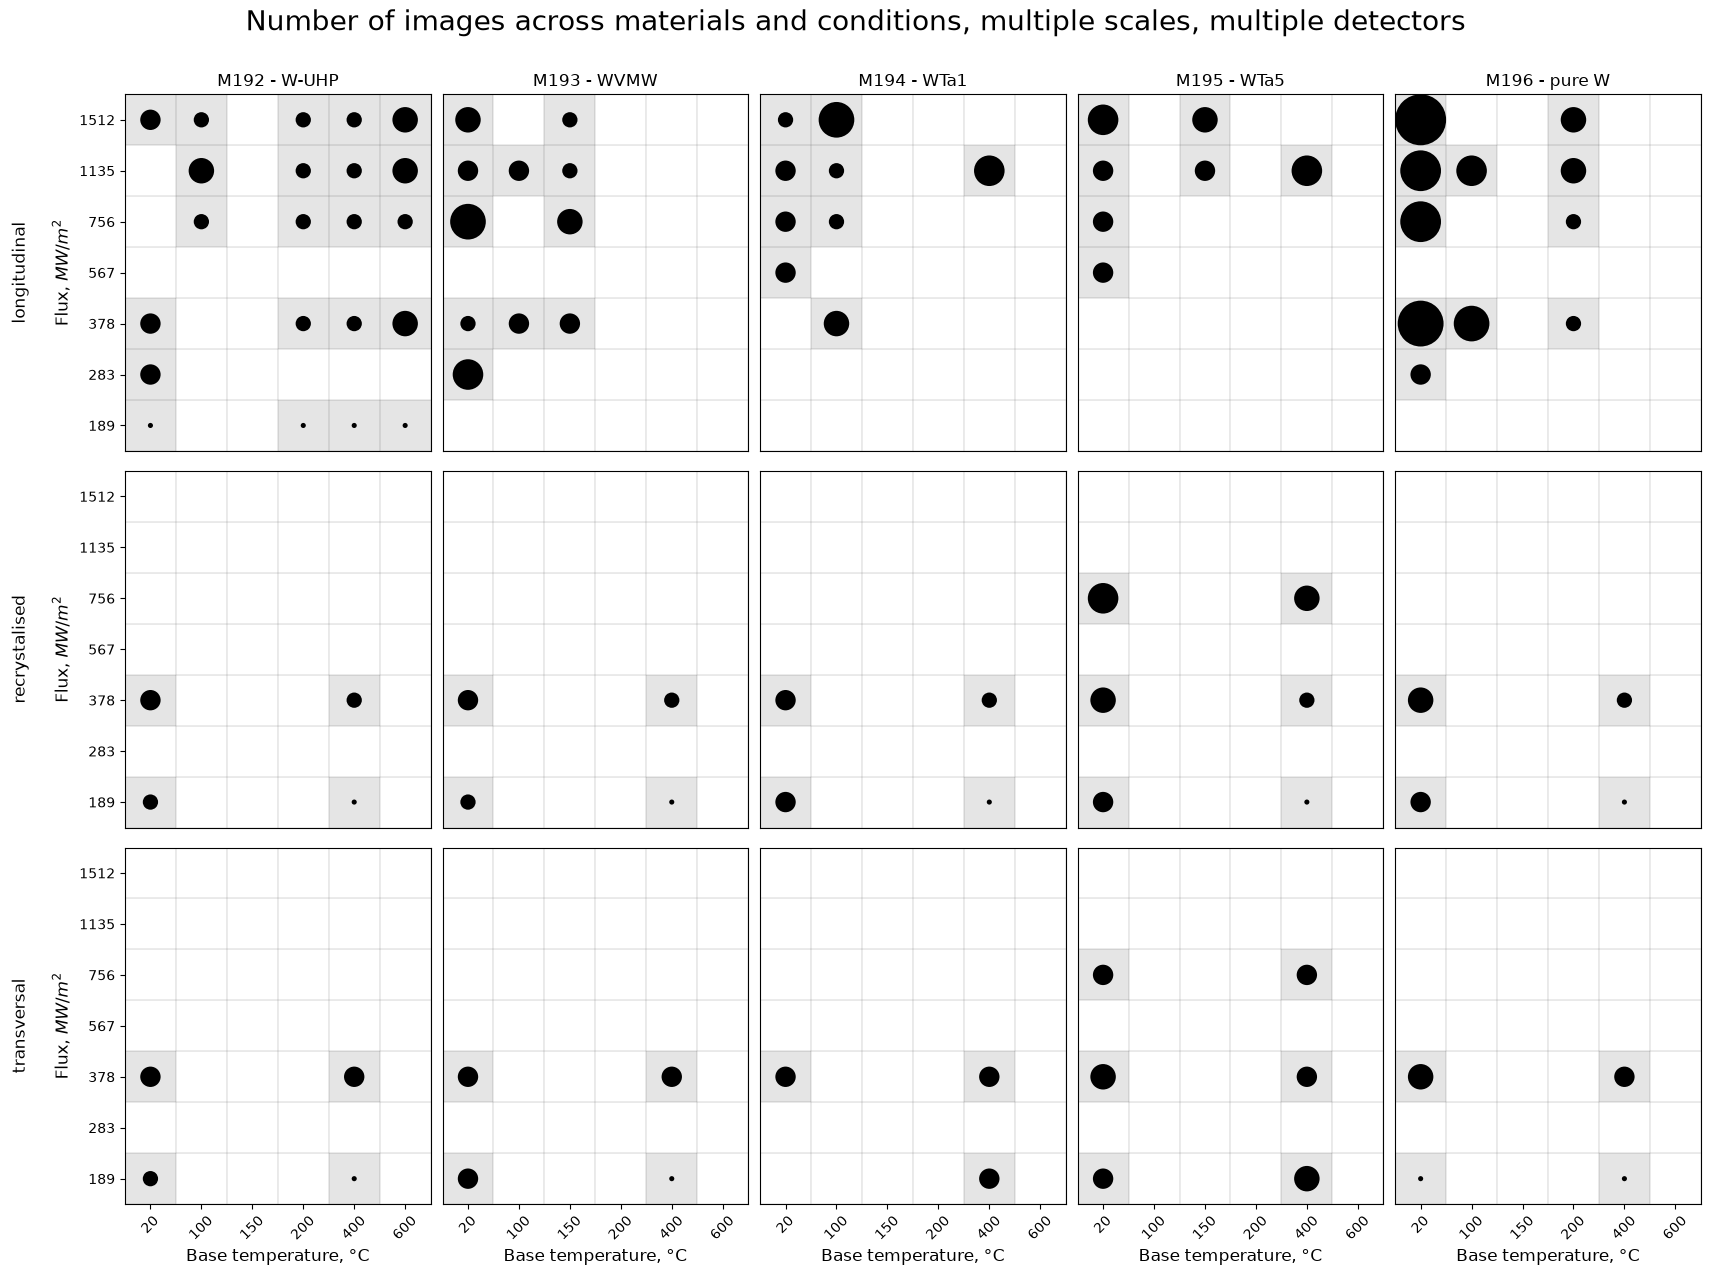

In [4]:
dataset.plot_test_matrix(field='num images', what_to_show='circle maps')

### Image data

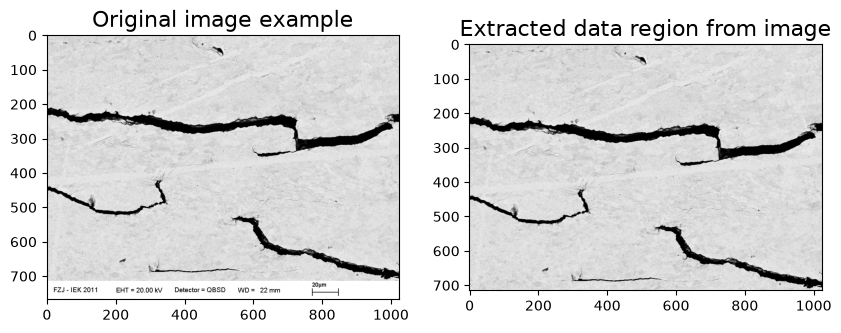

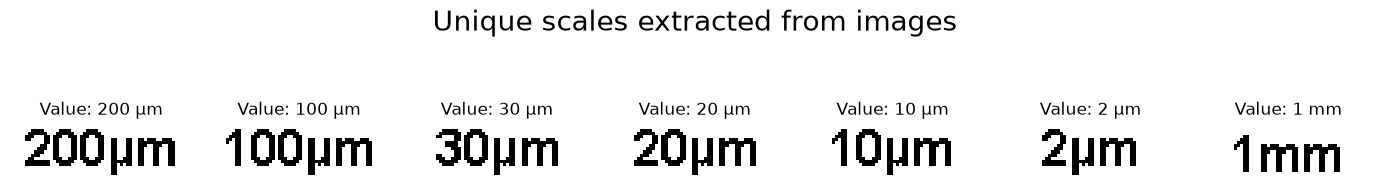

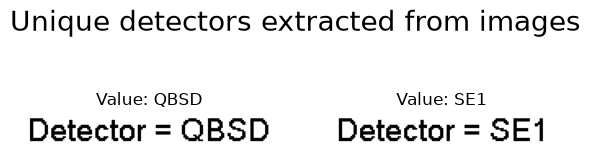

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(dataset.images[0], cmap='gray')
axes[0].set_title('Original image example', fontsize=16)
# axes[0].axis('off')
axes[1].imshow(dataset.data[0], cmap='gray')
axes[1].set_title('Extracted data region from image', fontsize=16)
# axes[1].axis('off')
plt.show()


unique_scales, unique_indices = np.unique(dataset.unique_visual['scale'], axis=0, return_index=True)
fig, axes = plt.subplots(1, len(unique_scales), figsize=(len(unique_scales)*2, 3))
for ax, sc, idx in zip(axes, unique_scales, unique_indices):
    ax.imshow(sc, cmap='gray')
    ax.set_title(f'Value: {fmt(dataset.scales[idx])}')
    ax.axis('off')
fig.tight_layout(rect=[0,0,1,1])
fig.suptitle('Unique scales extracted from images', fontsize=20)
plt.show()


unique_detectors, unique_indices = np.unique(dataset.unique_visual['detector'], axis=0, return_index=True)
fig, axes = plt.subplots(1, len(unique_detectors), figsize=(len(unique_detectors)*3, 2.5))
for ax, det, idx in zip(axes, unique_detectors, unique_indices):
    ax.axis('off')
    ax.imshow(det, cmap='gray')
    ax.set_title(f'Value: {dataset.detectors[idx]}')
fig.tight_layout(rect=[0,0,1,1])
fig.suptitle('Unique detectors extracted from images', fontsize=20)
plt.show()

### Data summary

Total images:     402
Image shape:      (768, 1024)
Data shape:       (715, 1024)
Num experiments:  110
Num materials:    5 ['M192 - W-UHP' 'M193 - WVMW' 'M194 - WTa1' 'M195 - WTa5' 'M196 - pure W']
Num load types:   3 ['longitudinal' 'recrystalised' 'transversal']
Num detectors:    2 ['QBSD' 'SE1']
Num scales:       7 [2.e-06 1.e-05 2.e-05 3.e-05 1.e-04 2.e-04 1.e-03]
Num resolutions:  44
Num resolutions < 5.e-6:  14 ['2.0e-08', '5.2e-08', '1.0e-07', '1.0e-07', '1.3e-07', '1.3e-07', '1.7e-07', '1.7e-07', '2.6e-07', '3.4e-07', '5.2e-07', '1.0e-06', '1.0e-06', '1.7e-06']
Num resolutions >= 5.e-6:  30 ['5.2e-06', '5.2e-06', '5.2e-06', '5.3e-06', '5.3e-06', '5.3e-06', '5.4e-06', '5.4e-06', '5.4e-06', '5.5e-06', '5.5e-06', '5.6e-06', '5.7e-06', '5.7e-06', '5.7e-06', '5.8e-06', '5.8e-06', '5.8e-06', '5.9e-06', '5.9e-06', '6.0e-06', '6.0e-06', '6.1e-06', '6.1e-06', '6.2e-06', '6.2e-06', '6.3e-06', '6.3e-06', '6.3e-06', '6.4e-06']
Num images with resolution < 5.e-6:  289


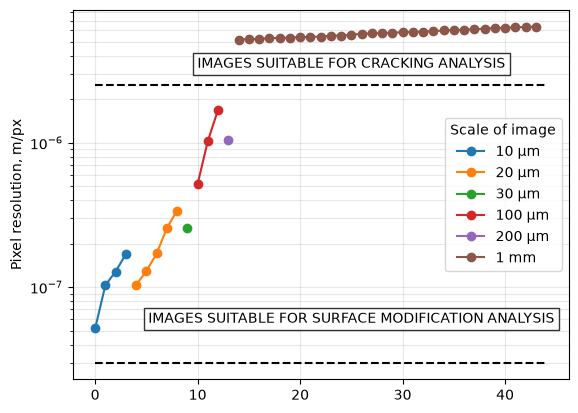

In [6]:
print("Total images:    ", len(dataset))
print("Image shape:     ", dataset.images[0].shape)
print("Data shape:      ", dataset.data[0].shape)
print("Num experiments: ", len(dataset.unique_meta['label']))
print("Num materials:   ", len(dataset.unique_meta['material']), dataset.unique_meta['material'])
print("Num load types:  ", len(dataset.unique_meta['loadtype']), dataset.unique_meta['loadtype'])
print("Num detectors:   ", len(dataset.unique_meta['detector']), dataset.unique_meta['detector'])
print("Num scales:      ", len(dataset.unique_meta['scale']), dataset.unique_meta['scale'])
print("Num resolutions: ", len(dataset.unique_meta['resolution']))
print("Num resolutions < 5.e-6: ",  len(dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] < 5.e-6]), [f'{r:.1e}' for r in dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] < 5.e-6]])
print("Num resolutions >= 5.e-6: ", len(dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] >= 5.e-6]), [f'{r:.1e}' for r in dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] >= 5.e-6]])
print("Num images with resolution < 5.e-6: ", np.sum(dataset.metadata['resolution'] < 5.e-6))


min_resolution = 3e-8
max_resolution = 2.5e-6
xind = [-1]
for sc in dataset.unique_meta['scale'][dataset.unique_meta['scale']>2e-6]:
    mask = dataset.metadata['scale']==sc
    res_sc  = np.unique(dataset.metadata['resolution'][mask])
    num_res = np.zeros(len(res_sc))
    for i, res in enumerate(res_sc):
        num_res[i] = np.sum(np.logical_and(mask, dataset.metadata['resolution']==res))
    num_res /= num_res.min()
    xind = xind[-1] + np.arange(1,len(res_sc)+1)
    plt.semilogy(xind, res_sc, '-o', label=f"{fmt(sc)}")
    # plt.semilogy(xind, res_sc, '-o', label=f"{sc:.0e} m".replace("e+0", "e+").replace("e-0", "e-"))
plt.hlines([min_resolution, max_resolution], xmin=0, xmax=xind[-1]+1, colors='k', linestyles='dashed')#, label='Resolution filter bounds')
plt.grid(True, which='both', alpha=0.3)
plt.ylabel('Pixel resolution, m/px')
# plt.title("Ordered pixel resolutions for each scale")
plt.legend(loc='right', title='Scale of image')
plt.text(25, 3.5e-6, "IMAGES SUITABLE FOR CRACKING ANALYSIS", ha="center", va="center", bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", pad=3))
plt.text(25, 6e-8, "IMAGES SUITABLE FOR SURFACE MODIFICATION ANALYSIS", ha="center", va="center", bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", pad=3))
plt.show()


display_styled(dataset.summary_table(), width="200%", cols=[1,9], max_height=None)
# print(dataset.summary_table().to_latex())

### Representative Images by Resolution

In [34]:
# Physical patch size to display (in meters)
patch_size_physical = 20e-6  # 20 micrometer

patch_dataset = JUDITHPatchDataset(fov=patch_size_physical, stride_ratio=0.8, preload=True)
patch_dataset_QBSD = patch_dataset.filter_by_metadata(detector='QBSD')

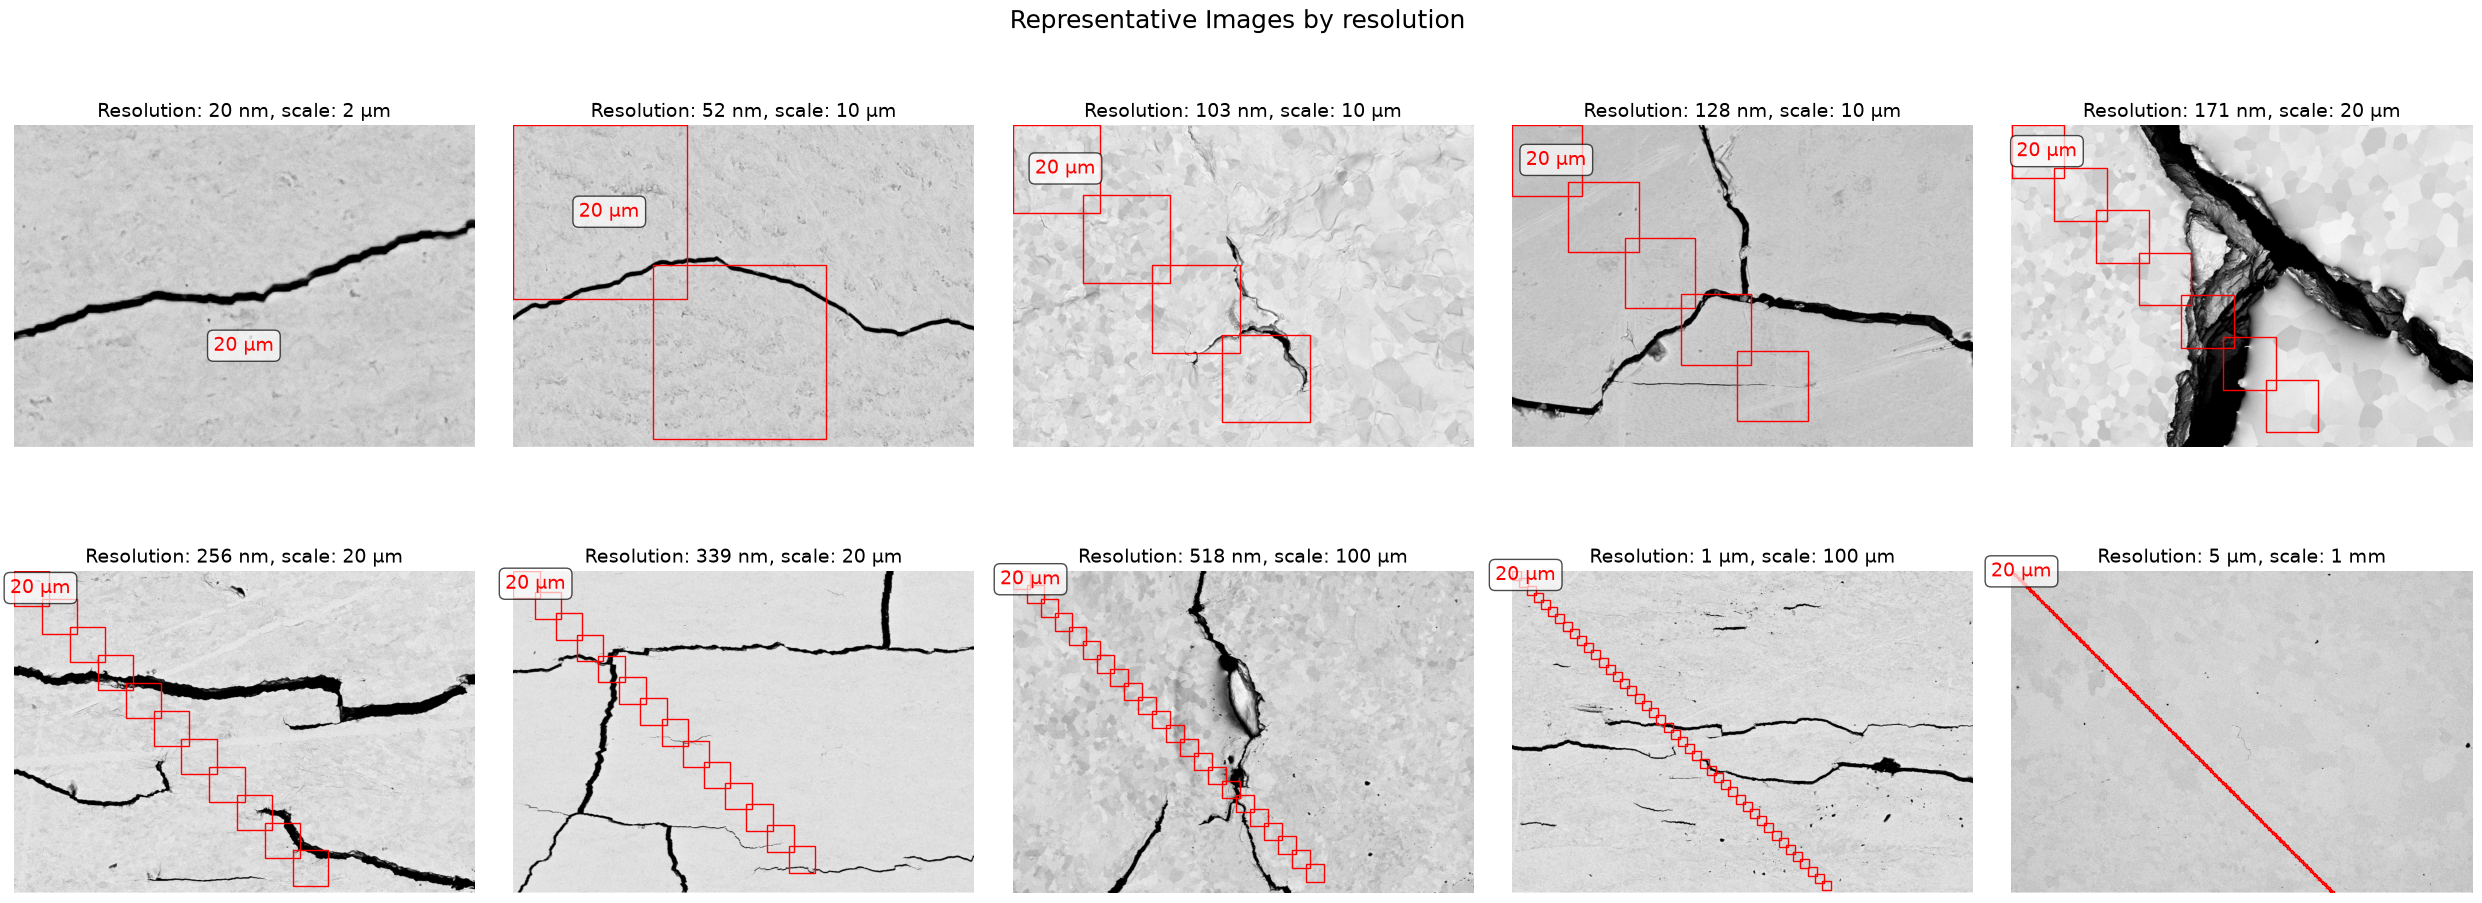

In [35]:
# Get representative resolutions as strings in scientific notation
resolutions_sci = np.array([float(f"{r:.1e}") for r in np.sort(patch_dataset_QBSD.unique_meta['resolution'])])
unique_resolution_str = [f'{ri:.1e}' for ri in resolutions_sci[np.r_[True, np.diff(resolutions_sci) > 0.05 * (resolutions_sci[:-1] + 1e-20)]]]

# Create a grid layout
n_resolutions = len(unique_resolution_str)
n_cols = min(5, n_resolutions)  # max 5 columns
n_rows = int(np.ceil(n_resolutions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
if n_resolutions == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, resolution in enumerate(unique_resolution_str):
    # Find first image with this resolution
    mask = np.array([f'{ri:.1e}' for ri in patch_dataset_QBSD.metadata['resolution']]) == resolution
    indices = np.where(mask)[0]

    if len(indices) > 0:
        img_idx = indices[0]
        patch_dataset_QBSD.plot_patch_overlays(img_idx, pattern='diagonal', show=False, ax=axes[idx])

# Hide unused subplots
for idx in range(n_resolutions, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Representative Images by resolution', fontsize=18, y=1.00)
plt.show()


### Representative Patches by Resolution

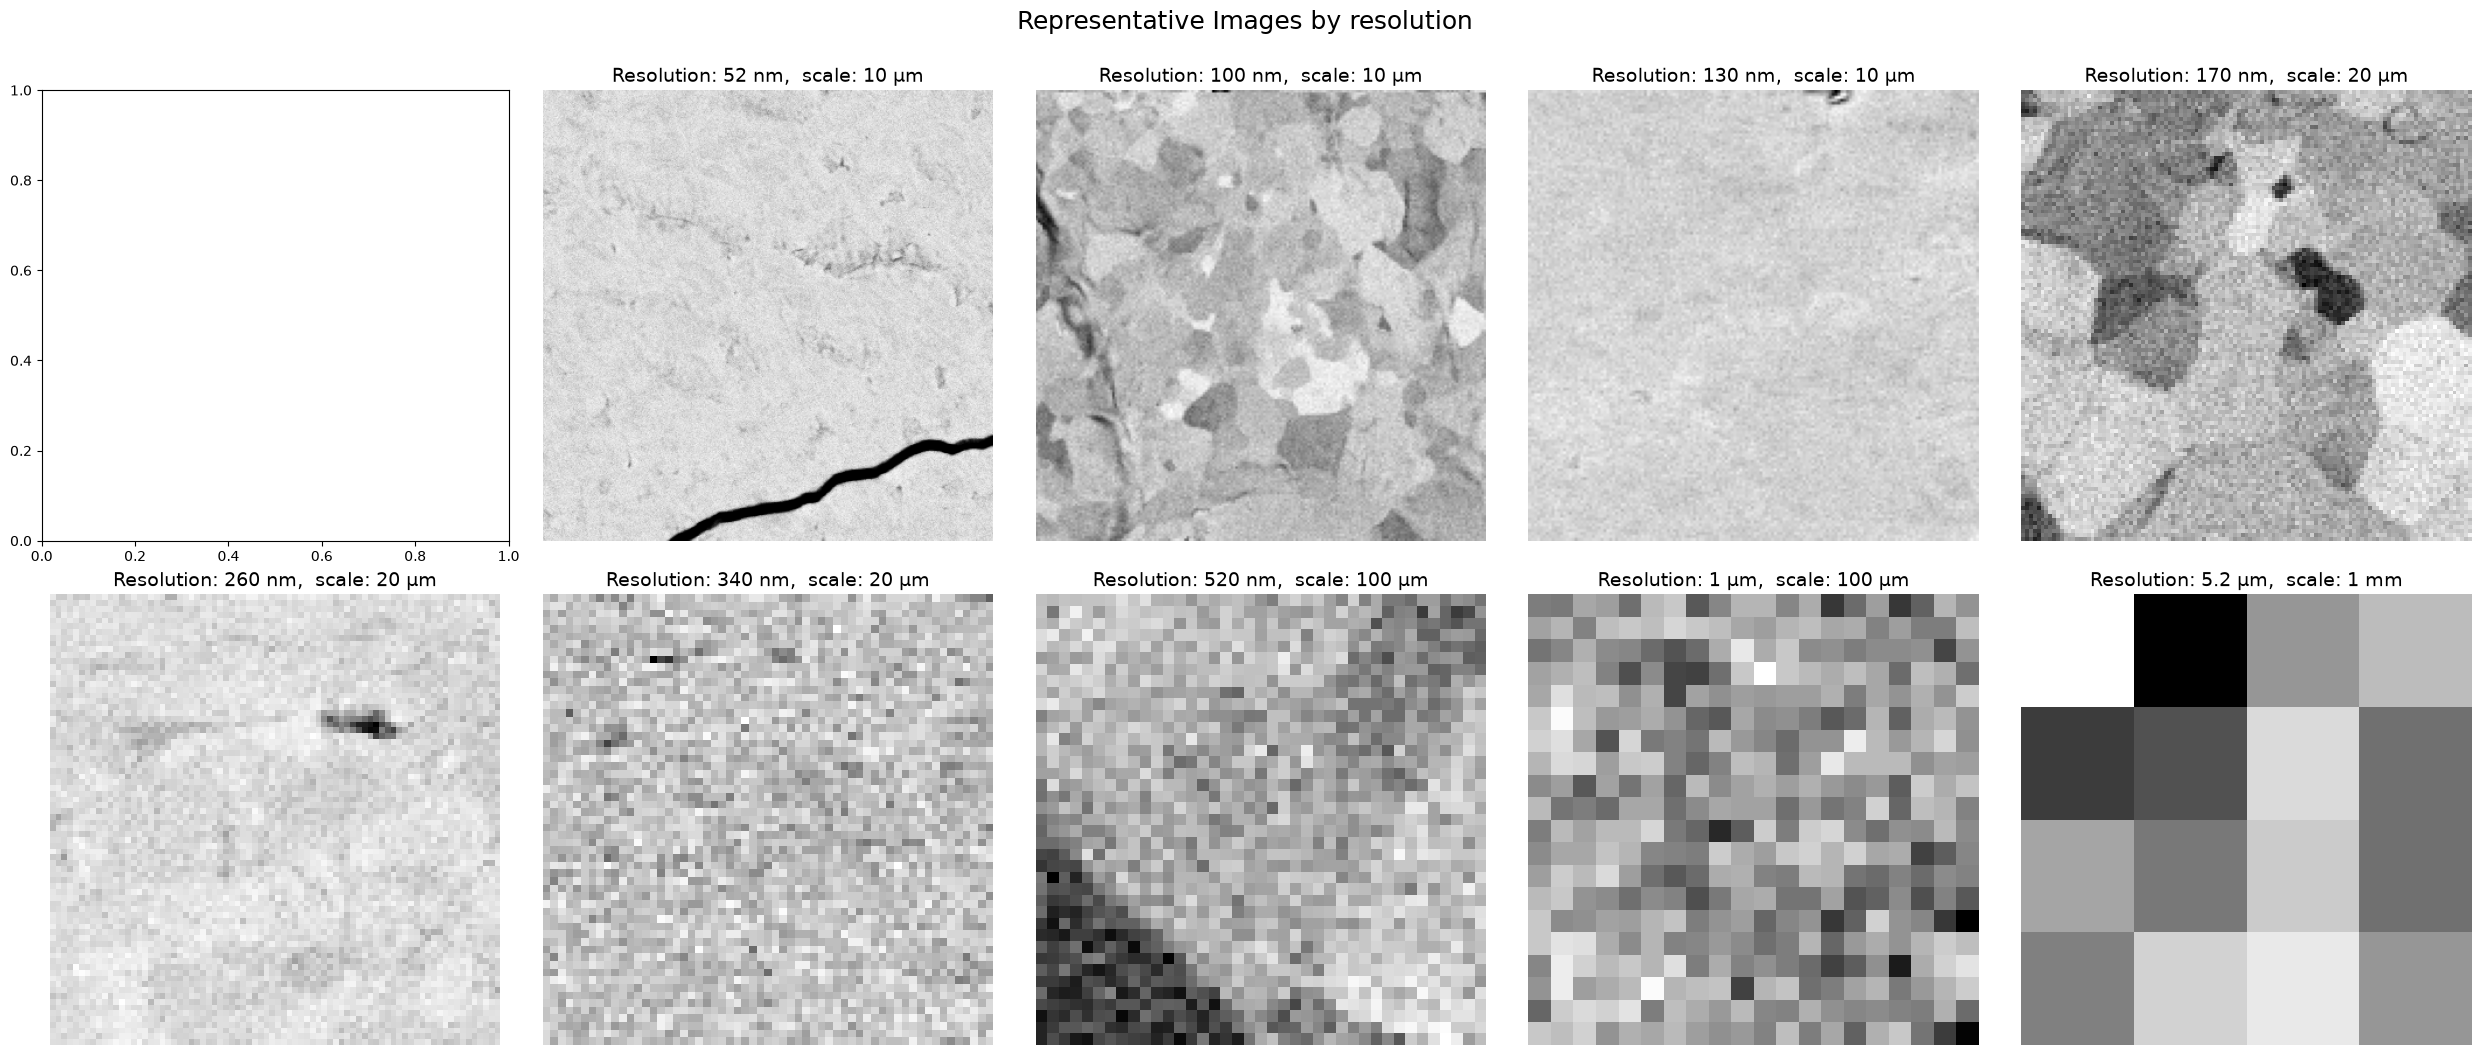

In [36]:
# Get representative resolutions as strings in scientific notation
resolutions_sci = np.array([float(f"{r:.1e}") for r in np.sort(patch_dataset_QBSD.unique_meta['resolution'])])
unique_resolution_str = [f'{ri:.1e}' for ri in resolutions_sci[np.r_[True, np.diff(resolutions_sci) > 0.05 * (resolutions_sci[:-1] + 1e-20)]]]

# Create a grid layout
n_resolutions = len(unique_resolution_str)
n_cols = min(5, n_resolutions)  # max 5 columns
n_rows = int(np.ceil(n_resolutions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
if n_resolutions == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, resolution in enumerate(unique_resolution_str):
    # Find first image with this resolution
    mask = np.array([f'{ri:.1e}' for ri in patch_dataset_QBSD.metadata['resolution']]) == resolution
    indices = np.where(mask)[0]

    if len(indices) > 0:
        img_idx = indices[0]
        patches = patch_dataset_QBSD.img_idx_to_patches(img_idx)
        if patches.size==0:
            continue
        axes[idx].imshow(patches[0], cmap="gray")
        axes[idx].set_title(f"Resolution: {fmt(float(resolution))},  scale: {fmt(patch_dataset_QBSD.metadata['scale'][img_idx])}", fontsize=14)
        axes[idx].axis("off")

# Hide unused subplots
for idx in range(n_resolutions, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Representative Images by resolution', fontsize=18, y=1.05)
plt.show()
